Đang đọc dữ liệu từ GARBAGE_CLASSIFICATION\train... vui lòng đợi!
Đã load xong 18649 ảnh và nhãn.
Đang đọc dữ liệu từ GARBAGE_CLASSIFICATION\valid... vui lòng đợi!
Đã load xong 2113 ảnh và nhãn.
Đang đọc dữ liệu từ GARBAGE_CLASSIFICATION\test... vui lòng đợi!
Đã load xong 2246 ảnh và nhãn.

Epoch 1/80
Train Loss: 1.7445 | Train Acc: 38.21%
Val Loss:   1.7030 | Val Acc:   18.08%
Đã lưu Model tốt nhất với Val Acc: 18.08%

Epoch 2/80
Train Loss: 1.4331 | Train Acc: 48.47%
Val Loss:   1.6006 | Val Acc:   28.02%
Đã lưu Model tốt nhất với Val Acc: 28.02%

Epoch 3/80
Train Loss: 1.3650 | Train Acc: 53.86%
Val Loss:   1.4287 | Val Acc:   47.28%
Đã lưu Model tốt nhất với Val Acc: 47.28%

Epoch 4/80
Train Loss: 1.3069 | Train Acc: 58.18%
Val Loss:   1.5628 | Val Acc:   35.21%

Epoch 5/80
Train Loss: 1.2618 | Train Acc: 60.53%
Val Loss:   1.2370 | Val Acc:   61.67%
Đã lưu Model tốt nhất với Val Acc: 61.67%

Epoch 6/80
Train Loss: 1.2340 | Train Acc: 62.13%
Val Loss:   1.2050 | Val Acc:   59.58%



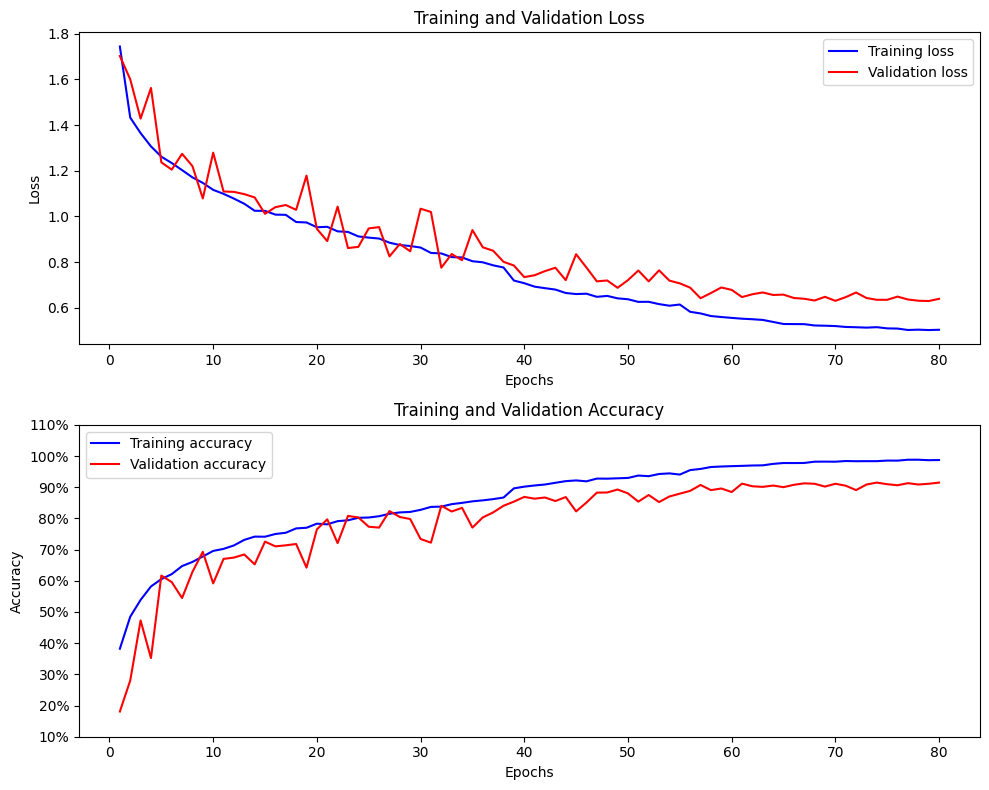

In [2]:
import torch 
import torch.nn as nn 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker 
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms 
from torch.optim import Adam 
from torch.optim.lr_scheduler import ReduceLROnPlateau
import os
from PIL import Image

%matplotlib inline 
device = 'cuda' if torch.cuda.is_available() else 'cpu' 

data_path = 'GARBAGE_CLASSIFICATION' 
img_size = 128
train_preprocess = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(), 
    transforms.RandomRotation(20),   
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

val_preprocess = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

class PLR(Dataset): 
    def __init__(self, folder_path, transform=None): 
        self.img_dir = os.path.join(folder_path, 'images')
        self.lbl_dir = os.path.join(folder_path, 'labels')
        self.transform = transform
        self.img_names = [f for f in os.listdir(self.img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

        self.labels = []
        print(f"Đang đọc dữ liệu từ {folder_path}... vui lòng đợi!")
        for img_name in self.img_names:
            txt_name = os.path.splitext(img_name)[0] + '.txt'
            txt_path = os.path.join(self.lbl_dir, txt_name)
            with open(txt_path, 'r') as f:
                self.labels.append(int(f.readline().strip().split()[0]))
        print(f"Đã load xong {len(self.labels)} ảnh và nhãn.")

    def __getitem__(self, ix): 
        img_name = self.img_names[ix]
        img_path = os.path.join(self.img_dir, img_name)
        x = Image.open(img_path).convert("RGB")
        if self.transform:
            x = self.transform(x)
            
        y = self.labels[ix]
        return x, torch.tensor(y)

    def __len__(self):  
        return len(self.img_names) 

num_classes = 0
with open(os.path.join(data_path, 'data.yaml'), 'r') as f:
    for line in f:
        if line.startswith('nc:'):
            num_classes = int(line.split(':')[1].strip())
            break
def get_data():  
    train = PLR(os.path.join(data_path, 'train'), transform=train_preprocess) 
    class_counts = [0] * num_classes
    for y in train.labels:
        class_counts[y] += 1
        
    class_weights = 1. / (np.array(class_counts) + 1e-6) 
    sample_weights = [class_weights[y] for y in train.labels]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    
    trn_dl = DataLoader(train, batch_size=128, sampler=sampler, num_workers=0, pin_memory=True) 
    
    val = PLR(os.path.join(data_path, 'valid'), transform=val_preprocess)  
    val_dl = DataLoader(val, batch_size=128, shuffle=False, num_workers=0, pin_memory=True)
    
    test = PLR(os.path.join(data_path, 'test'), transform=val_preprocess)  
    test_dl = DataLoader(test, batch_size=128, shuffle=False, num_workers=0, pin_memory=True)
    
    return trn_dl, val_dl, test_dl 

def get_model(num_classes): 
    model = nn.Sequential( 
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
        nn.Conv2d(128, 256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
        nn.Conv2d(256, 512, kernel_size=3, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),

        nn.Flatten(),
        nn.Linear(512 * 4 * 4, 512), 
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    ).to(device) 

    loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-4) 
    return model, loss_fn, optimizer
trn_dl, val_dl, test_dl = get_data() 
model, loss_fn, optimizer = get_model(num_classes) 

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

train_losses, train_accuracies = [], [] 
val_losses, val_accuracies = [], [] 

best_val_acc = 0.0
best_model_path = 'GARBAGE_CLASSIFICATION_cnn_model.pth'

EPOCHS = 80

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}") 
    
    model.train()
    train_epoch_losses = [] 
    correct_train = 0
    total_train = 0
    
    for x, y in trn_dl: 
        x, y = x.to(device), y.to(device) 
        
        optimizer.zero_grad() 
        prediction = model(x) 
        batch_loss = loss_fn(prediction, y) 
        batch_loss.backward() 
        optimizer.step()
        
        train_epoch_losses.append(batch_loss.item())  
        
        _, predicted = torch.max(prediction.data, 1)
        total_train += y.size(0)
        correct_train += (predicted == y).sum().item()

    train_epoch_loss = np.mean(train_epoch_losses) 
    train_epoch_accuracy = correct_train / total_train

    model.eval()
    val_epoch_losses = []
    correct_val = 0
    total_val = 0
    
    with torch.no_grad(): 
        for x, y in val_dl: 
            x, y = x.to(device), y.to(device) 
            
            prediction = model(x) 
            v_loss = loss_fn(prediction, y) 
            val_epoch_losses.append(v_loss.item())
            
            _, predicted = torch.max(prediction.data, 1)
            total_val += y.size(0)
            correct_val += (predicted == y).sum().item()

    val_epoch_loss = np.mean(val_epoch_losses)
    val_epoch_accuracy = correct_val / total_val

    train_losses.append(train_epoch_loss) 
    train_accuracies.append(train_epoch_accuracy) 
    val_losses.append(val_epoch_loss) 
    val_accuracies.append(val_epoch_accuracy) 
    
    print(f"Train Loss: {train_epoch_loss:.4f} | Train Acc: {train_epoch_accuracy*100:.2f}%")
    print(f"Val Loss:   {val_epoch_loss:.4f} | Val Acc:   {val_epoch_accuracy*100:.2f}%")

    scheduler.step(val_epoch_loss)
    
    if val_epoch_accuracy > best_val_acc:
        best_val_acc = val_epoch_accuracy
        torch.save(model.state_dict(), best_model_path)
        print(f"Đã lưu Model tốt nhất với Val Acc: {best_val_acc*100:.2f}%")

epochs_range = np.arange(len(train_losses)) + 1 
plt.figure(figsize=(10, 8))
plt.subplot(211) 
plt.plot(epochs_range, train_losses, 'b-', label='Training loss') 
plt.plot(epochs_range, val_losses, 'r-', label='Validation loss') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(10)) 
plt.title('Training and Validation Loss') 
plt.xlabel('Epochs') 
plt.ylabel('Loss') 
plt.legend() 

plt.subplot(212) 
plt.plot(epochs_range, train_accuracies, 'b-', label='Training accuracy') 
plt.plot(epochs_range, val_accuracies, 'r-', label='Validation accuracy') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(10)) 
plt.title('Training and Validation Accuracy') 
plt.xlabel('Epochs') 
plt.ylabel('Accuracy') 
ticks = plt.gca().get_yticks()
plt.gca().set_yticks(ticks)
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in ticks])  
plt.legend() 
plt.tight_layout()
plt.show()

In [ ]:
correct = 0  
total = 0 
model.eval() 
model.load_state_dict(torch.load(best_model_path))
with torch.no_grad():  
    for images, labels in test_dl:  
        images, labels = images.to(device), labels.to(device)  
        outputs = model(images)  
        _, predicted = torch.max(outputs.data, 1)  
        total += labels.size(0)  
        correct += (predicted == labels).sum().item()  
print(f"Độ chính xác trên tập test: {100 * correct / total:.2f}%")

C:\Users\T.Hung\AppData\Local\Temp\ipykernel_3768\879147799.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


Độ chính xác trên tập test: 92.88%
